# 02_feature_engineering_and_train.ipynb

This notebook loads preprocessed taxi demand data, performs feature engineering, trains a LightGBM model, and exports it to ONNX.

## 1. Import required libraries

In [3]:
import polars as pl
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta

# ONNX libraries
from onnxmltools import convert_lightgbm
from skl2onnx.common.data_types import FloatTensorType, Int64TensorType


## 2. Load preprocessed data

Load `aggregated_demand_3min.parquet` generated in the previous step.

In [4]:
RECENT_MONTHS = 6  # Use full history when None
TEST_MONTHS = 1  # Use the last N months of the selected range as test
FEATURE_MODE = "lite"  # "lite" or "full"
HORIZON_STEPS = 5  # 5 steps at 3-minute granularity -> 15 minutes ahead

processed_data_path = "../data/processed/aggregated_demand_3min.parquet"

if not os.path.exists(processed_data_path):
    raise FileNotFoundError(f"Data not found at {processed_data_path}")

df = pl.read_parquet(processed_data_path)

# Optimize data types
df = df.with_columns([
    pl.col("PULocationID").cast(pl.Int32),
    pl.col("demand").cast(pl.Float32),
])

# Sort by zone/time for stable time-series operations
df = df.sort(["PULocationID", "pickup_time"])

# Keep only the most recent N months
if RECENT_MONTHS is not None:
    max_ts = df.select(pl.max("pickup_time")).item()
    cutoff = max_ts - timedelta(days=30 * RECENT_MONTHS)
    df = df.filter(pl.col("pickup_time") >= cutoff)
    print(f"Using recent {RECENT_MONTHS} months: {cutoff} ~ {max_ts}")


Using recent 6 months: 2025-06-03 00:00:00 ~ 2025-11-30 00:00:00


In [5]:
# Time features
df = df.with_columns(
    pl.col("pickup_time").dt.hour().cast(pl.Int32).alias("hour"),
    pl.col("pickup_time").dt.weekday().cast(pl.Int32).alias("day_of_week"),
    ((pl.col("pickup_time").dt.weekday() >= 6).cast(pl.Int32)).alias("is_weekend")
)

# Base lag features (kept simple for operations)
df = df.with_columns([
    pl.col("demand").shift(20).over("PULocationID").alias("demand_lag_20"),
])

# Create additional features only in `full` mode
if FEATURE_MODE == "full":
    df = df.with_columns([
        pl.col("demand").shift(1).over("PULocationID").alias("demand_lag_1"),
        pl.col("demand").shift(5).over("PULocationID").alias("demand_lag_5"),
        pl.col("demand").rolling_mean(window_size=20, min_samples=1).over("PULocationID").alias("rolling_mean_20"),
    ])

# Create target: demand at a single timestamp 15 minutes ahead (=3 min * 5)
df = df.with_columns(
    pl.col("demand").shift(-HORIZON_STEPS).over("PULocationID").alias("target")
)

# Handle nulls and drop the tail without target values
df = df.fill_null(0.0)
df = df.filter(pl.col("target").is_not_null())


## 4. Data split (time-based)

For time-series data, never shuffle. Split train/test strictly by time.
- **Train data**: data before December 31, 2024
- **Test data**: data from January 1, 2025 onward

In [6]:
# Dynamic time-based split: use the latest timestamp and reserve the last TEST_MONTHS as test
max_ts = df.select(pl.max("pickup_time")).item()
split_date = max_ts - timedelta(days=30 * TEST_MONTHS)

train_df = df.filter(pl.col("pickup_time") < split_date)
test_df = df.filter(pl.col("pickup_time") >= split_date)

print(f"Split date: {split_date}")
print(f"Train samples: {len(train_df):,}")
print(f"Test samples:  {len(test_df):,}")

if len(train_df) == 0 or len(test_df) == 0:
    raise ValueError("Empty train/test split. Adjust RECENT_MONTHS or TEST_MONTHS.")

base_features = ["PULocationID", "hour", "day_of_week", "is_weekend"]
lite_features = base_features + ["demand_lag_20"]
full_features = base_features + ["demand_lag_1", "demand_lag_5", "demand_lag_20", "rolling_mean_20"]

if FEATURE_MODE == "full":
    features = full_features
else:
    features = lite_features

target = "target"
print(f"Feature mode: {FEATURE_MODE}")
print(f"Features: {features}")

X_train = train_df.select(features)
y_train = train_df.select(target).to_series()
X_test = test_df.select(features)
y_test = test_df.select(target).to_series()


Split date: 2025-10-31 00:00:00
Train samples: 18,534,194
Test samples:  3,513,754
Feature mode: lite
Features: ['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'demand_lag_20']


## 5. Train LightGBM model

Train the model with `LightGBMRegressor`.
Treat `PULocationID` as a categorical feature.

In [7]:
lgbm = lgb.LGBMRegressor(
    objective='mae', 
    n_estimators=1000, 
    learning_rate=0.05, 
    num_leaves=31, 
    random_state=42
)

categorical_feats = [f for f in ["PULocationID", "hour", "day_of_week", "is_weekend"] if f in features]

print("Training started...")
lgbm.fit(
    X_train.to_pandas(), y_train.to_pandas(),
    categorical_feature=categorical_feats,
    eval_set=[(X_test.to_pandas(), y_test.to_pandas())],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50)]
)

Training started...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.274664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 332
[LightGBM] [Info] Number of data points in the train set: 18534194, number of used features: 5
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.401109


LGBMRegressor(learning_rate=0.05, n_estimators=1000, objective='mae',
              random_state=42)

## 6. Model evaluation and visualization

Compute MAE/RMSE on the test set and visualize actual vs predicted values.

Making predictions on the test set...

--- Model Evaluation ---
Mean Absolute Error (MAE): 0.4011
Root Mean Squared Error (RMSE): 1.3205

Generating visualization for PULocationID 132 from 2025-11-23 to 2025-11-30...


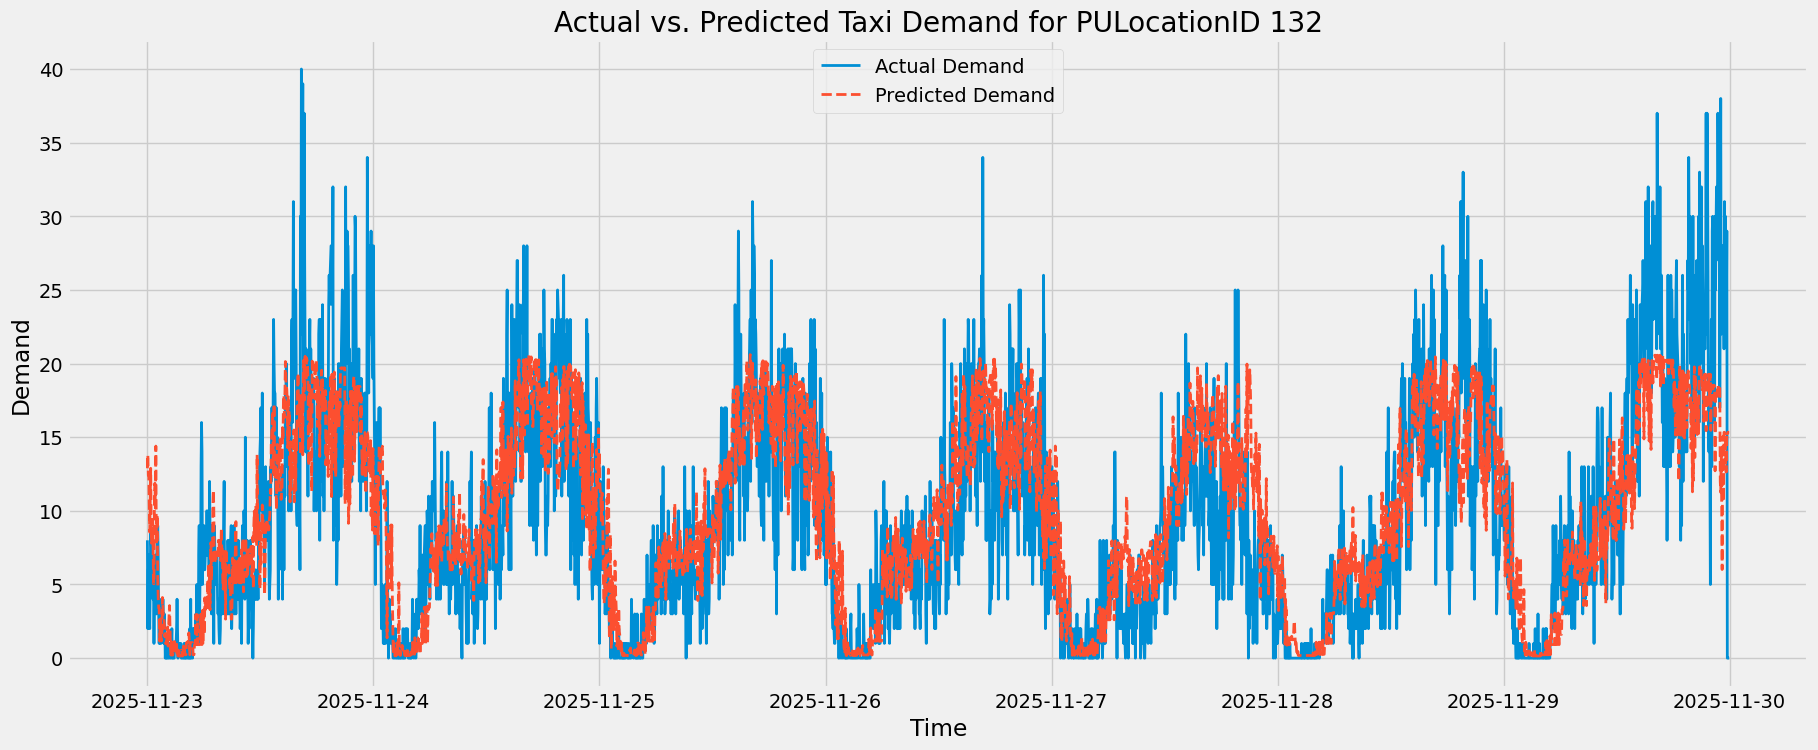

In [8]:
# 1) Convert to pandas once for evaluation
print("Making predictions on the test set...")
X_test_pd = X_test.to_pandas()
y_test_pd = y_test.to_pandas()

y_pred = lgbm.predict(X_test_pd)

# 2) Evaluate model performance
mae = mean_absolute_error(y_test_pd, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_pd, y_pred))

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")

# 3) Merge outputs for visualization
results_df = test_df.with_columns(
    pl.Series(name="predicted_demand", values=y_pred)
)

# 4) Set visualization window dynamically from recent data (avoid fixed 2025-01-01)
location_to_plot = 132
max_ts = results_df.select(pl.max("pickup_time")).item()
start_date = max_ts - timedelta(days=7)
end_date = max_ts

sample_vis_df = results_df.filter(
    (pl.col("PULocationID") == location_to_plot) &
    (pl.col("pickup_time") >= start_date) &
    (pl.col("pickup_time") < end_date)
)

print(f"Generating visualization for PULocationID {location_to_plot} from {start_date.date()} to {end_date.date()}...")

plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(sample_vis_df["pickup_time"], sample_vis_df["target"], label="Actual Demand", linewidth=2)
ax.plot(sample_vis_df["pickup_time"], sample_vis_df["predicted_demand"], label="Predicted Demand", linestyle="--", linewidth=2)
ax.set_title(f"Actual vs. Predicted Taxi Demand for PULocationID {location_to_plot}")
ax.set_xlabel("Time")
ax.set_ylabel("Demand")
ax.legend()
plt.grid(True)
plt.show()

## 6-1. Detailed error analysis (zone/time/baseline/bias)


In [9]:
# `results_df`: `test_df` with `predicted_demand` (created in the previous cell)
eval_df = (
    results_df
    .select(["PULocationID", "pickup_time", "day_of_week", "hour", "demand", "target", "predicted_demand"])
    .with_columns([
        (pl.col("predicted_demand") - pl.col("target")).alias("residual"),
        (pl.col("predicted_demand") - pl.col("target")).abs().alias("abs_error"),
        ((pl.col("predicted_demand") - pl.col("target")) ** 2).alias("sq_error"),
    ])
)

# 1) Zone-level MAE/RMSE/bias
zone_metrics = (
    eval_df
    .group_by("PULocationID")
    .agg([
        pl.mean("target").alias("mean_actual"),
        pl.mean("abs_error").alias("mae"),
        pl.mean("sq_error").sqrt().alias("rmse"),
        pl.mean("residual").alias("residual_mean"),
        pl.len().alias("n"),
    ])
    .sort("mean_actual", descending=True)
)

hot_th = zone_metrics.select(pl.col("mean_actual").quantile(0.8)).item()
low_th = zone_metrics.select(pl.col("mean_actual").quantile(0.2)).item()

hot_zone_summary = zone_metrics.filter(pl.col("mean_actual") >= hot_th).select([
    pl.mean("mae").alias("hot_mae"),
    pl.mean("rmse").alias("hot_rmse"),
    pl.mean("residual_mean").alias("hot_bias"),
    pl.len().alias("hot_zone_count"),
]).to_dicts()[0]

low_zone_summary = zone_metrics.filter(pl.col("mean_actual") <= low_th).select([
    pl.mean("mae").alias("low_mae"),
    pl.mean("rmse").alias("low_rmse"),
    pl.mean("residual_mean").alias("low_bias"),
    pl.len().alias("low_zone_count"),
]).to_dicts()[0]

print("--- Zone-level Error Summary ---")
print(f"Hot zones(top 20%)  MAE={hot_zone_summary['hot_mae']:.4f}, RMSE={hot_zone_summary['hot_rmse']:.4f}, Bias={hot_zone_summary['hot_bias']:.4f}, Zones={hot_zone_summary['hot_zone_count']}")
print(f"Low zones(bottom 20%) MAE={low_zone_summary['low_mae']:.4f}, RMSE={low_zone_summary['low_rmse']:.4f}, Bias={low_zone_summary['low_bias']:.4f}, Zones={low_zone_summary['low_zone_count']}")
print()

print("Top 10 high-demand zones by mean actual demand:")
print(zone_metrics.head(10))
print()

# 2) Peak-time errors (commute/weekend)
segment_df = eval_df.with_columns([
    (
        (pl.col("day_of_week") <= 5)
        & (
            ((pl.col("hour") >= 7) & (pl.col("hour") < 10))
            | ((pl.col("hour") >= 17) & (pl.col("hour") < 20))
        )
    ).alias("is_commute_peak"),
    (pl.col("day_of_week") >= 6).alias("is_weekend"),
])

segment_metrics = pl.DataFrame({
    "segment": ["weekday_commute_peak", "weekend", "overall"],
    "mae": [
        segment_df.filter(pl.col("is_commute_peak")).select(pl.mean("abs_error")).item(),
        segment_df.filter(pl.col("is_weekend")).select(pl.mean("abs_error")).item(),
        segment_df.select(pl.mean("abs_error")).item(),
    ],
    "rmse": [
        segment_df.filter(pl.col("is_commute_peak")).select(pl.mean("sq_error").sqrt()).item(),
        segment_df.filter(pl.col("is_weekend")).select(pl.mean("sq_error").sqrt()).item(),
        segment_df.select(pl.mean("sq_error").sqrt()).item(),
    ],
})

print("--- Time Segment Error ---")
print(segment_metrics)
print()

# 3) Improvement over naive baseline
# naive: y_hat(t+h) = demand(t)
naive_mae = eval_df.select((pl.col("demand") - pl.col("target")).abs().mean()).item()
naive_rmse = eval_df.select(((pl.col("demand") - pl.col("target")) ** 2).mean().sqrt()).item()
model_mae = eval_df.select(pl.mean("abs_error")).item()
model_rmse = eval_df.select(pl.mean("sq_error").sqrt()).item()

mae_improve_pct = (naive_mae - model_mae) / naive_mae * 100 if naive_mae else float('nan')
rmse_improve_pct = (naive_rmse - model_rmse) / naive_rmse * 100 if naive_rmse else float('nan')

print("--- Baseline Comparison (naive: y(t+h)=demand(t)) ---")
print(f"Naive MAE={naive_mae:.4f}, Model MAE={model_mae:.4f}, Improvement={mae_improve_pct:.2f}%")
print(f"Naive RMSE={naive_rmse:.4f}, Model RMSE={model_rmse:.4f}, Improvement={rmse_improve_pct:.2f}%")
print()

# 4) Under/over-prediction bias
overall_bias = eval_df.select(pl.mean("residual")).item()
under_rate = eval_df.select((pl.col("residual") < 0).mean()).item()
over_rate = eval_df.select((pl.col("residual") > 0).mean()).item()

print("--- Bias Check ---")
print(f"Residual mean (pred-actual): {overall_bias:.6f}")
print(f"Under-prediction rate: {under_rate*100:.2f}%")
print(f"Over-prediction rate:  {over_rate*100:.2f}%")

print()
print("Worst 10 zones by MAE:")
print(zone_metrics.sort("mae", descending=True).head(10))


--- Zone-level Error Summary ---
Hot zones(top 20%)  MAE=1.7253, RMSE=2.5463, Bias=-0.6211, Zones=51
Low zones(bottom 20%) MAE=0.0044, RMSE=0.0585, Bias=-0.0043, Zones=51

Top 10 high-demand zones by mean actual demand:
shape: (10, 6)
┌──────────────┬─────────────┬──────────┬──────────┬───────────────┬───────┐
│ PULocationID ┆ mean_actual ┆ mae      ┆ rmse     ┆ residual_mean ┆ n     │
│ ---          ┆ ---         ┆ ---      ┆ ---      ┆ ---           ┆ ---   │
│ f64          ┆ f32         ┆ f64      ┆ f64      ┆ f64           ┆ u32   │
╞══════════════╪═════════════╪══════════╪══════════╪═══════════════╪═══════╡
│ 237.0        ┆ 12.324445   ┆ 3.717055 ┆ 5.379902 ┆ -2.134769     ┆ 14400 │
│ 161.0        ┆ 11.024375   ┆ 3.402246 ┆ 4.995259 ┆ -1.394496     ┆ 14400 │
│ 132.0        ┆ 10.624375   ┆ 3.93109  ┆ 5.282624 ┆ -0.218435     ┆ 14400 │
│ 236.0        ┆ 10.242881   ┆ 3.261907 ┆ 4.906345 ┆ -1.847218     ┆ 14398 │
│ 186.0        ┆ 7.943403    ┆ 3.43006  ┆ 4.891506 ┆ -1.148515     ┆ 144

## 7. Export to ONNX model

Convert the trained LightGBM model to ONNX and save it as `models/taxi_demand_model.onnx`.

When converting to ONNX, define input schema (types and shapes) precisely.

In [10]:
print("Exporting to ONNX for Flink...")

# [Update 3] Configure a single array input named `float_input` for Flink serving
# Java side example: `float[] input = {zone_id, hour, ...};`
n_features = len(features)
initial_types = [('float_input', FloatTensorType([None, n_features]))]

# ONNX conversion
onnx_model = convert_lightgbm(
    lgbm, 
    initial_types=initial_types, 
    target_opset=13
)

# Store feature order in metadata (useful for verifying Java-side input order)
meta = onnx_model.metadata_props.add()
meta.key = "feature_names"
meta.value = ",".join(features)

save_path = "../models/taxi_demand_model.onnx"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"SUCCESS: Model saved to {save_path}")
print(f"Input Features Order for Flink: {features}")

Exporting to ONNX for Flink...
SUCCESS: Model saved to ../models/taxi_demand_model.onnx
Input Features Order for Flink: ['PULocationID', 'hour', 'day_of_week', 'is_weekend', 'demand_lag_20']


## 8. ONNX model verification (optional)

Quickly verify that the saved ONNX model loads and produces predictions. `onnxruntime` is required.

In [11]:
onnx_model_path = "../models/taxi_demand_model.onnx"

try:
    import onnxruntime as rt

    sess = rt.InferenceSession(onnx_model_path)
    input_infos = sess.get_inputs()
    output_name = sess.get_outputs()[0].name

    # Run ONNX prediction on a test sample
    # Convert inputs to the shape expected by the ONNX model.
    # For LightGBM conversion, a common pattern is a single `FloatTensorType([None, num_features])` input.
    
    # `onnxmltools.convert_lightgbm` can also expose per-feature inputs.
    # Build the input dictionary according to `initial_type_flat`.
    
    # Example: prepare inputs for one-row prediction
    sample_input = X_test.head(1).select(features)

    if len(input_infos) == 1:
        # Single-tensor input: shape = (N, F)
        input_name = input_infos[0].name
        x_np = sample_input.to_numpy().astype(np.float32)
        onnx_pred = sess.run([output_name], {input_name: x_np})[0]
    else:
        # Per-feature input tensors
        onnx_input_dict = {}
        type_map = {inp.name: inp.type.lower() for inp in input_infos}
        for name in features:
            arr = sample_input[name].to_numpy().reshape(1, 1)
            if "int64" in type_map.get(name, "") or "int32" in type_map.get(name, ""):
                onnx_input_dict[name] = arr.astype(np.int64)
            else:
                onnx_input_dict[name] = arr.astype(np.float32)
        onnx_pred = sess.run([output_name], onnx_input_dict)[0]

    print(f"\nONNX model loaded and tested. Sample prediction: {onnx_pred[0][0]:.4f}")
    print(f"Corresponding LightGBM prediction: {lgbm.predict(sample_input.to_pandas())[0]:.4f}")

except ImportError:
    print("\nonnxruntime not installed. Skipping ONNX model verification. Run `pip install onnxruntime` to enable.")
except Exception as e:
    print(f"\nError during ONNX model verification: {e}")



ONNX model loaded and tested. Sample prediction: 0.0000
Corresponding LightGBM prediction: 0.0000


## 8-1. ONNX multi-sample parity check

Compare LightGBM and ONNX predictions on multiple samples to verify conversion parity.


In [12]:
import numpy as np

try:
    import onnxruntime as rt

    onnx_model_path = '../models/taxi_demand_model.onnx'
    sess = rt.InferenceSession(onnx_model_path)

    input_name = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    n_samples = min(1000, len(X_test))
    sample_df = X_test.head(n_samples)
    sample_pd = sample_df.to_pandas().astype(np.float32)

    # LightGBM prediction
    lgb_pred = lgbm.predict(sample_pd).astype(np.float32).reshape(-1)

    # ONNX prediction
    onnx_out = sess.run([output_name], {input_name: sample_pd.to_numpy(np.float32)})[0]
    onnx_pred = np.array(onnx_out).reshape(-1).astype(np.float32)

    abs_diff = np.abs(lgb_pred - onnx_pred)

    print(f'Compared samples: {n_samples:,}')
    print(f'Mean abs diff: {abs_diff.mean():.10f}')
    print(f'Median abs diff: {np.median(abs_diff):.10f}')
    print(f'P95 abs diff: {np.quantile(abs_diff, 0.95):.10f}')
    print(f'Max abs diff: {abs_diff.max():.10f}')

    tol = 1e-5
    pass_rate = (abs_diff <= tol).mean() * 100
    print(f'Pass rate (<= {tol}): {pass_rate:.2f}%')

except ImportError:
    print('onnxruntime not installed. Run: pip install onnxruntime')
except Exception as e:
    print(f'Error during multi-sample ONNX consistency check: {e}')


Compared samples: 1,000
Mean abs diff: 0.0000000000
Median abs diff: 0.0000000000
P95 abs diff: 0.0000000000
Max abs diff: 0.0000000001
Pass rate (<= 1e-05): 100.00%
